# Парсинг данных

Парсинг https://www.numbeo.com/quality-of-life/rankings.jsp

In [1]:
import time
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
from requests.adapters import HTTPAdapter, Retry

BASE_URL = "https://www.numbeo.com/quality-of-life/rankings.jsp"
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36")
}

def make_session():
    s = requests.Session()
    retries = Retry(total=3, backoff_factor=1, status_forcelist=(429, 500, 502, 503, 504))
    s.mount("https://", HTTPAdapter(max_retries=retries))
    s.headers.update(HEADERS)
    return s


In [2]:
def parse_numbeo_table(html):
    soup = BeautifulSoup(html, "lxml")

    table = soup.find("table", class_="table_indices")
    if table is None:
        table = soup.find("table", class_=re.compile("tablesorter|table.*indices"))
    if table is None:
        tables = soup.find_all("table")
        if tables:
            table = max(tables, key=lambda t: len(t.find_all("tr")))
        else:
            return []

    headers = []
    thead = table.find("thead")
    if thead:
        headers = [th.get_text(strip=True) for th in thead.find_all("th")]
    else:
        first = table.find("tr")
        if first:
            headers = [td.get_text(strip=True) for td in first.find_all(["th","td"])]

    rows = []
    for tr in table.find_all("tr"):
        cols = tr.find_all("td")
        if not cols:
            continue
        texts = [td.get_text(" ", strip=True).replace('\xa0',' ').strip() for td in cols]
        if len(texts) >= 11:
            city_full = texts[1]
            country = None
            city = city_full
            if ',' in city_full:
                parts = [p.strip() for p in city_full.split(',')]
                country = parts[-1]
                city = ','.join(parts[:-1]).strip()
            row = {
                "Rank": try_parse_numeric(texts[0]),
                "City_raw": city_full,
                "City": city,
                "Country": country,
                "Quality of Life Index": try_parse_float(texts[2]),
                "Purchasing Power Index": try_parse_float(texts[3]),
                "Safety Index": try_parse_float(texts[4]),
                "Health Care Index": try_parse_float(texts[5]),
                "Cost of Living Index": try_parse_float(texts[6]),
                "Property Price to Income Ratio": try_parse_float(texts[7]),
                "Traffic Commute Time Index": try_parse_float(texts[8]),
                "Pollution Index": try_parse_float(texts[9]),
                "Climate Index": try_parse_float(texts[10]),
            }
        else:
            row = {}
            for i, t in enumerate(texts, 1):
                row[f"col{i}"] = t
        rows.append(row)
    return rows

def try_parse_float(s):
    if s is None:
        return None
    s = s.strip()
    s2 = re.sub(r'[^\d\.\-]', '', s.replace(',', '.'))
    try:
        return float(s2) if s2 != '' else None
    except:
        return None

def try_parse_numeric(s):
    try:
        return int(re.sub(r'[^\d\-]', '', s))
    except:
        return None


In [3]:
def scrape_numbeo_qol(pages=1, delay=1.0, verbose=True):
    session = make_session()
    all_rows = []
    for p in tqdm(range(1, pages+1), desc="pages", disable=not verbose):
        params = {"page": p} if p > 1 else {}
        try:
            resp = session.get(BASE_URL, params=params, timeout=20)
            resp.raise_for_status()
            html = resp.text
            part = parse_numbeo_table(html)
            if not part and verbose:
                print(f"Страница {p}: таблица не распознана или пустая.")
            all_rows.extend(part)
        except Exception as e:
            print(f"Ошибка при загрузке страницы {p}: {e}")
        time.sleep(delay)
    if not all_rows:
        return pd.DataFrame()
    df = pd.DataFrame(all_rows)
    if 'Country' in df.columns and df['Country'].isnull().any():
        df['Country'] = df.apply(lambda r: r['Country'] if pd.notna(r['Country']) else extract_country_from_raw(r.get('City_raw','')), axis=1)
    return df

def extract_country_from_raw(s):
    if not s:
        return None
    if ',' in s:
        parts = [p.strip() for p in s.split(',')]
        return parts[-1]
    return None


In [4]:
pages = 1
delay = 1.2

df = scrape_numbeo_qol(pages=pages, delay=delay, verbose=True)
print(f"Получено строк: {len(df)}")
display(df.head(10))

out_csv = "numbeo_qol.csv"
df.to_csv(out_csv, index=False, encoding='utf-8')
print("Сохранено в", out_csv)


pages:   0%|          | 0/1 [00:00<?, ?it/s]

Получено строк: 279


,Rank,City_raw,City,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
0,None,"The Hague (Den Haag), Netherlands",The Hague (Den Haag),Netherlands,235.1,165.7,80.0,82.7,67.7,5.7,20.6,17.5,90.6
1,None,"Groningen, Netherlands",Groningen,Netherlands,229.1,161.8,77.9,78.6,61.0,5.2,20.1,18.8,83.5
2,None,"Eindhoven, Netherlands",Eindhoven,Netherlands,226.6,159.2,79.1,80.4,66.3,6.5,22.7,19.2,85.4
3,None,"Bern, Switzerland",Bern,Switzerland,219.9,192.2,77.6,71.3,103.4,8.9,34.5,19.7,76.0
4,None,"Utrecht, Netherlands",Utrecht,Netherlands,216.4,140.3,78.0,83.6,69.0,8.4,22.6,21.9,87.2
5,None,"Basel, Switzerland",Basel,Switzerland,216.2,200.8,70.7,69.5,110.7,8.8,33.0,27.9,82.8
6,None,"Stavanger, Norway",Stavanger,Norway,215.4,142.2,76.7,71.8,79.0,6.2,24.7,13.1,80.0
7,None,"Valencia, Spain",Valencia,Spain,214.2,136.6,65.0,81.2,46.8,6.7,21.5,21.7,93.8
8,None,"Luxembourg, Luxembourg",Luxembourg,Luxembourg,213.6,164.0,71.3,76.2,74.2,10.4,27.4,21.2,82.6
9,None,"Rotterdam, Netherlands",Rotterdam,Netherlands,213.4,134.0,73.7,82.7,69.9,7.1,21.0,22.2,87.9


Сохранено в numbeo_qol.csv


In [5]:
df['City'] = df['City'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df['Country'] = df['Country'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df.dropna(subset=['City']).reset_index(drop=True)
numeric_cols = ['Quality of Life Index','Purchasing Power Index','Safety Index',
                'Health Care Index','Cost of Living Index','Property Price to Income Ratio',
                'Traffic Commute Time Index','Pollution Index','Climate Index']
available_numeric = [c for c in numeric_cols if c in df.columns]
print("Доступные числовые колонки:", available_numeric)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
display(df[ ['City','Country'] + available_numeric ].head())


Доступные числовые колонки: ['Quality of Life Index', 'Purchasing Power Index', 'Safety Index', 'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio', 'Traffic Commute Time Index', 'Pollution Index', 'Climate Index']


,City,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
0,The Hague (Den Haag),Netherlands,235.1,165.7,80.0,82.7,67.7,5.7,20.6,17.5,90.6
1,Groningen,Netherlands,229.1,161.8,77.9,78.6,61.0,5.2,20.1,18.8,83.5
2,Eindhoven,Netherlands,226.6,159.2,79.1,80.4,66.3,6.5,22.7,19.2,85.4
3,Bern,Switzerland,219.9,192.2,77.6,71.3,103.4,8.9,34.5,19.7,76.0
4,Utrecht,Netherlands,216.4,140.3,78.0,83.6,69.0,8.4,22.6,21.9,87.2


In [6]:
len(df)

279

# Загрузка спарсенных данных

In [7]:
import pandas as pd, numpy as np, os
fn = "numbeo_qol.csv"
df = pd.read_csv(fn, encoding='utf-8')
df.columns = [c.strip() for c in df.columns]
print("Dataset shape:", df.shape)
display(df.head(10))
display(df.info())

Dataset shape: (279, 13)


,Rank,City_raw,City,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
0,NaN,"The Hague (Den Haag), Netherlands",The Hague (Den Haag),Netherlands,235.1,165.7,80.0,82.7,67.7,5.7,20.6,17.5,90.6
1,NaN,"Groningen, Netherlands",Groningen,Netherlands,229.1,161.8,77.9,78.6,61.0,5.2,20.1,18.8,83.5
2,NaN,"Eindhoven, Netherlands",Eindhoven,Netherlands,226.6,159.2,79.1,80.4,66.3,6.5,22.7,19.2,85.4
3,NaN,"Bern, Switzerland",Bern,Switzerland,219.9,192.2,77.6,71.3,103.4,8.9,34.5,19.7,76.0
4,NaN,"Utrecht, Netherlands",Utrecht,Netherlands,216.4,140.3,78.0,83.6,69.0,8.4,22.6,21.9,87.2
5,NaN,"Basel, Switzerland",Basel,Switzerland,216.2,200.8,70.7,69.5,110.7,8.8,33.0,27.9,82.8
6,NaN,"Stavanger, Norway",Stavanger,Norway,215.4,142.2,76.7,71.8,79.0,6.2,24.7,13.1,80.0
7,NaN,"Valencia, Spain",Valencia,Spain,214.2,136.6,65.0,81.2,46.8,6.7,21.5,21.7,93.8
8,NaN,"Luxembourg, Luxembourg",Luxembourg,Luxembourg,213.6,164.0,71.3,76.2,74.2,10.4,27.4,21.2,82.6
9,NaN,"Rotterdam, Netherlands",Rotterdam,Netherlands,213.4,134.0,73.7,82.7,69.9,7.1,21.0,22.2,87.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            0 non-null      float64
 1   City_raw                        279 non-null    object 
 2   City                            279 non-null    object 
 3   Country                         279 non-null    object 
 4   Quality of Life Index           279 non-null    float64
 5   Purchasing Power Index          279 non-null    float64
 6   Safety Index                    279 non-null    float64
 7   Health Care Index               279 non-null    float64
 8   Cost of Living Index            279 non-null    float64
 9   Property Price to Income Ratio  279 non-null    float64
 10  Traffic Commute Time Index      279 non-null    float64
 11  Pollution Index                 279 non-null    float64
 12  Climate Index                   279 

None

# Предобработка

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [9]:
df_clean = df.drop_duplicates(subset=['City', 'Country'], keep='first').reset_index(drop=True)

print(f"Исходный размер: {df.shape}")
print(f"Размер после удаления дубликатов: {df_clean.shape}")

Исходный размер: (279, 13)
Размер после удаления дубликатов: (279, 13)


In [10]:
numeric_cols = [
    'Quality of Life Index', 'Purchasing Power Index', 'Safety Index',
    'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio',
    'Traffic Commute Time Index', 'Pollution Index', 'Climate Index'
]

X = df_clean[numeric_cols].copy()
display(X.describe().round(3))

,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
count,279.000,279.000,279.000,279.000,279.000,279.000,279.000,279.000,279.000
mean,156.227,107.537,56.726,66.844,52.857,11.505,35.485,49.848,77.629
std,37.754,43.736,15.161,8.631,19.521,7.387,8.784,20.277,17.300
min,8.200,10.900,18.200,38.700,17.100,1.700,17.900,12.400,14.300
25%,129.850,66.300,45.900,61.700,36.100,6.750,29.150,33.050,67.800
50%,160.800,115.500,56.800,67.300,54.700,10.400,34.500,49.000,81.800
75%,186.550,140.900,69.550,72.850,66.500,14.350,40.800,64.100,90.600
max,235.100,200.800,88.800,87.100,112.500,54.100,70.000,95.700,99.900


# EDA

<Figure size 1500x1500 with 0 Axes>

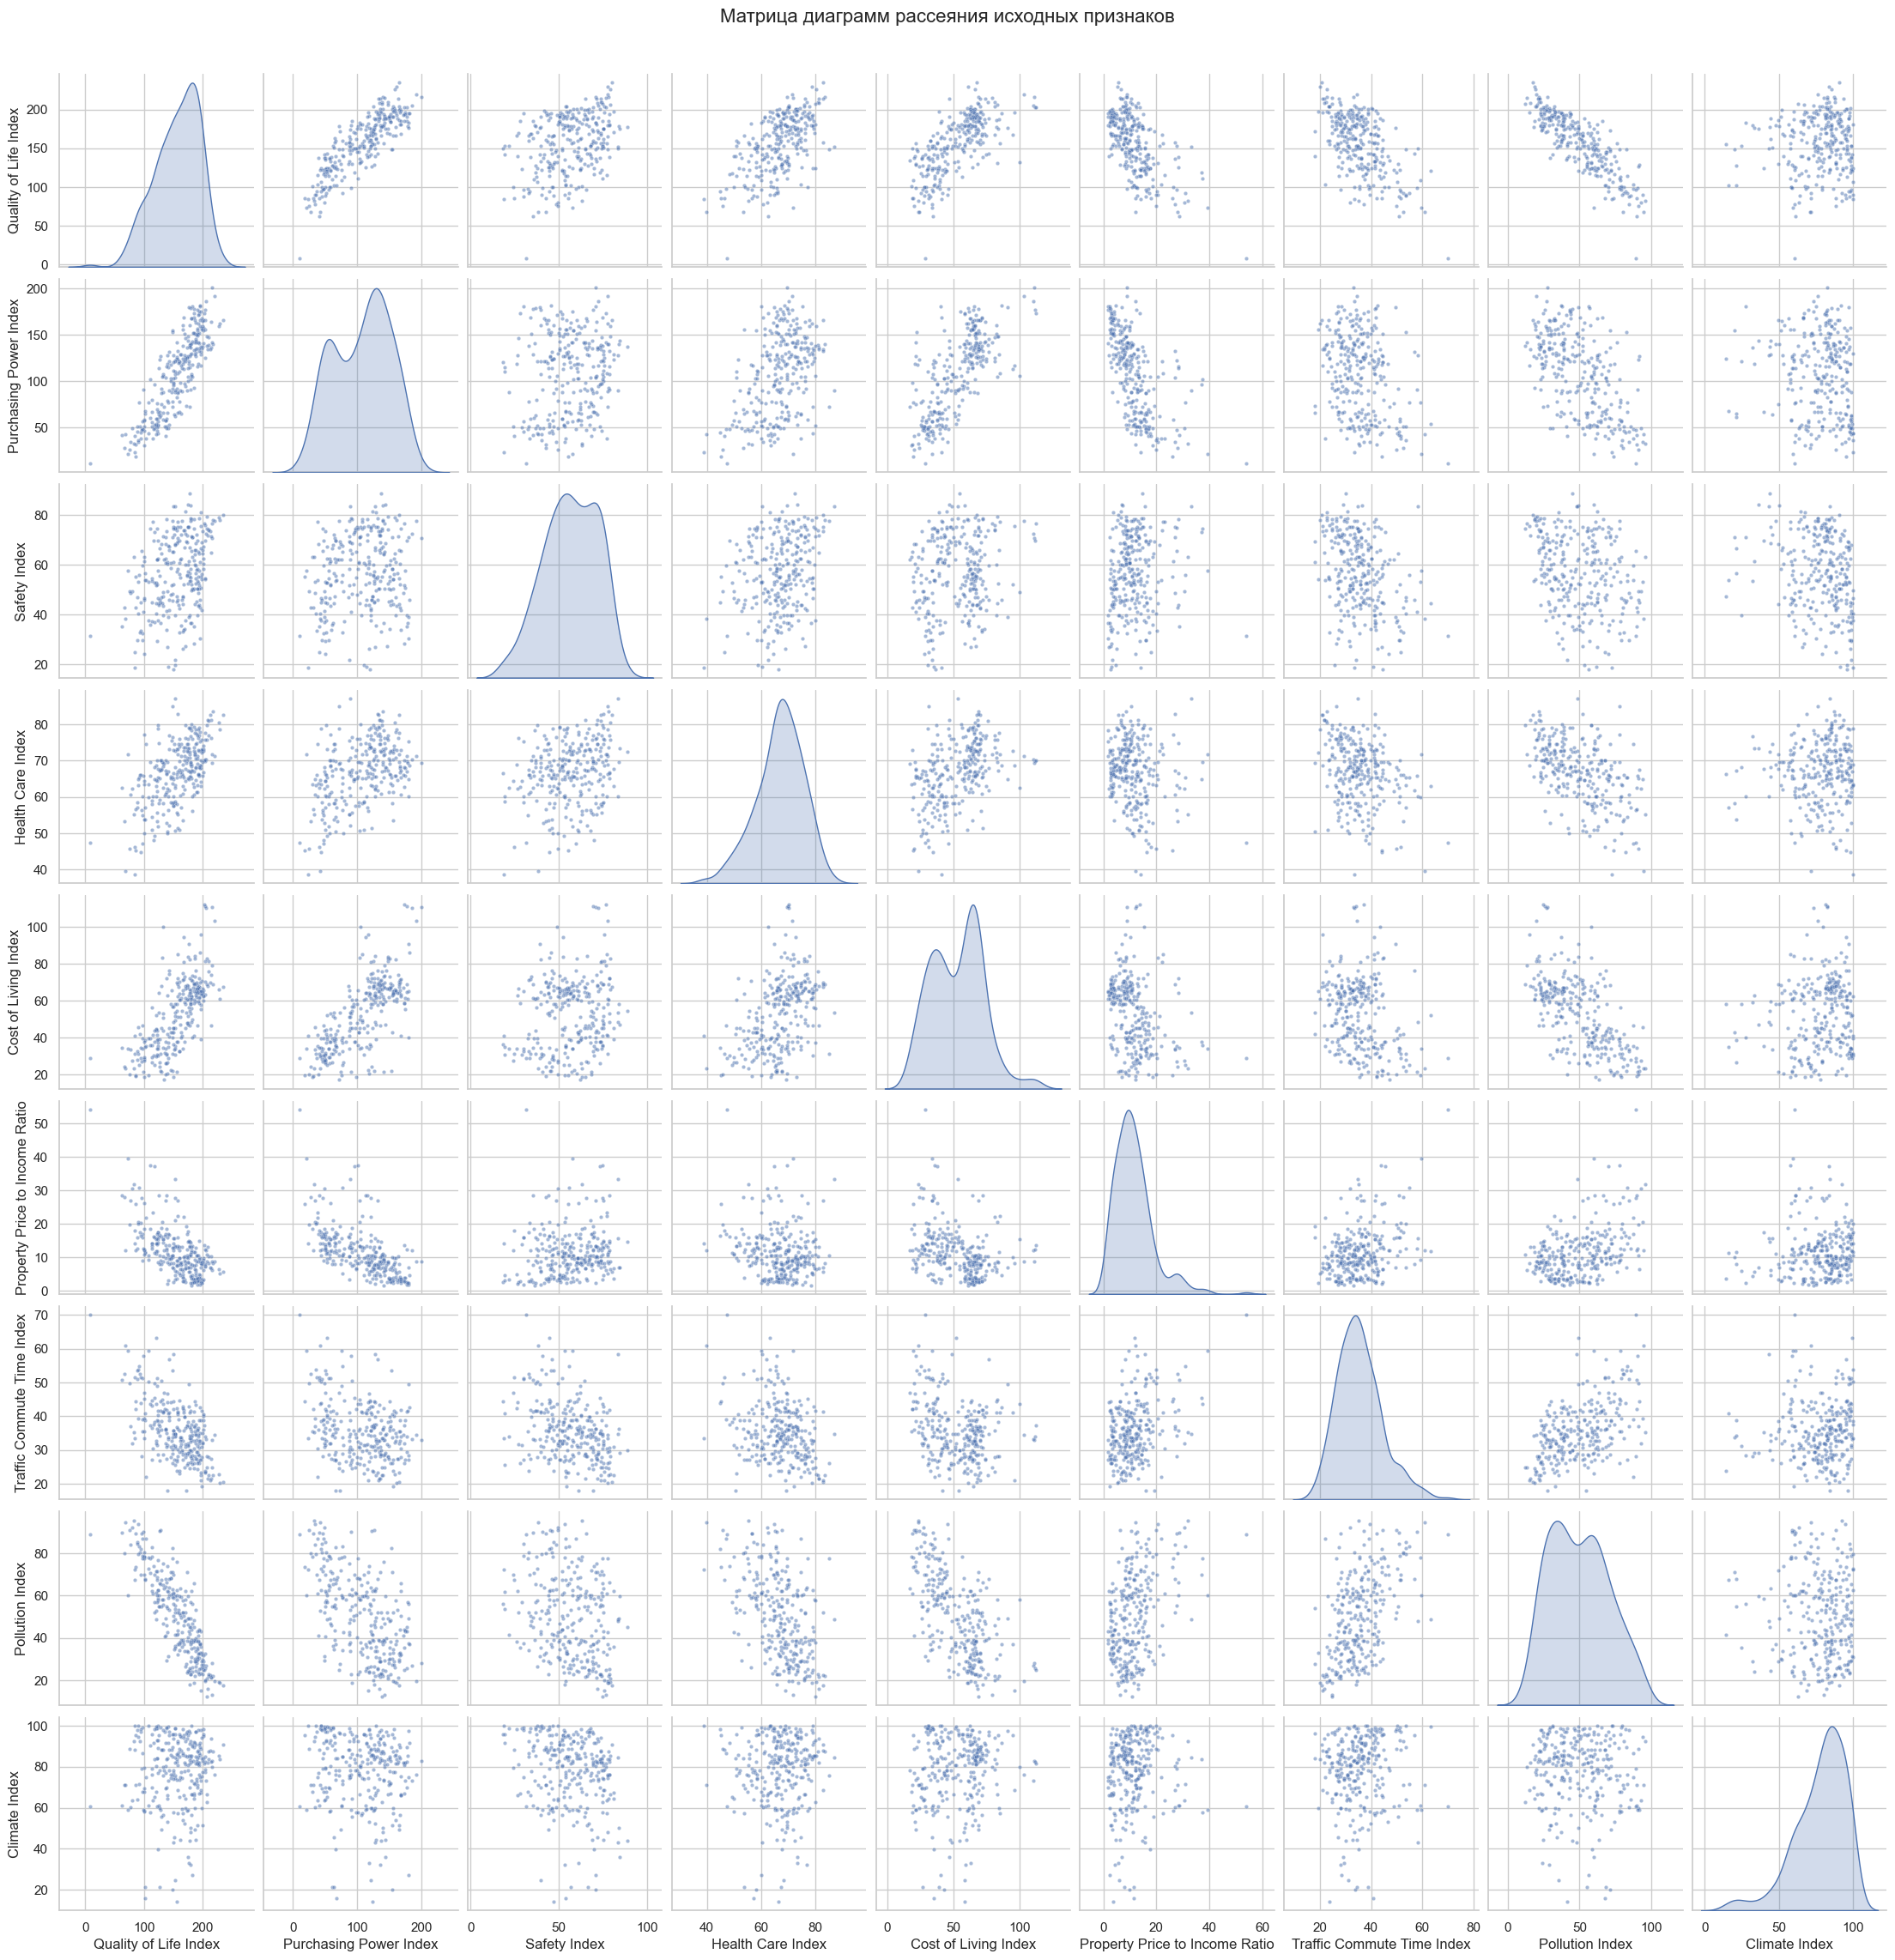

In [11]:
plt.figure(figsize=(15, 15))
sns.pairplot(
    df_clean[numeric_cols], 
    diag_kind='kde', 
    plot_kws={'alpha': 0.5, 's': 10}
)
plt.suptitle("Матрица диаграмм рассеяния исходных признаков", y=1.02, fontsize=16)
plt.show()

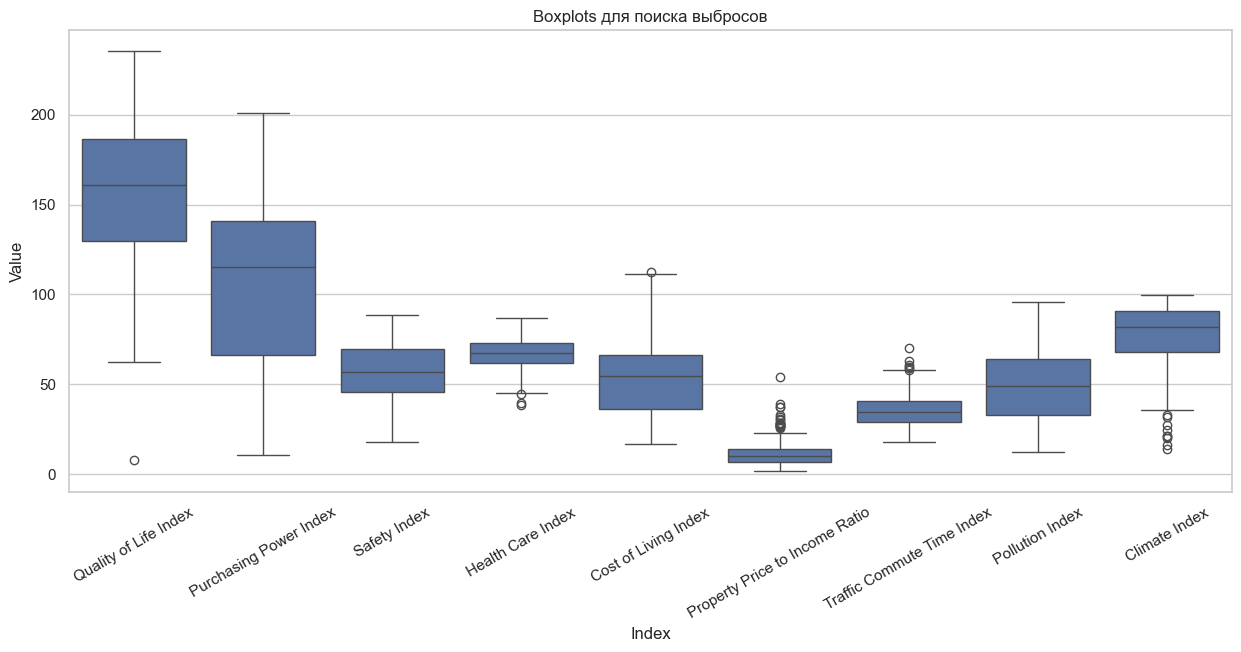

In [12]:
plt.figure(figsize=(15, 6))
X_melted = X.melt(var_name='Index', value_name='Value')
sns.boxplot(x='Index', y='Value', data=X_melted)
plt.xticks(rotation=30)
plt.title("Boxplots для поиска выбросов")
plt.show()

Данные содержат значимое количество выбросов. Для масштабирования желательно использовать методы, устойчивые к выбросам (StandardScaler может быть сильно смещен, поэтому в идеале лучше подошел бы RobustScaler, но StandardScaler допустим при последующей очистке).

Используем метод Спирмена, так как он устойчив к выбросам

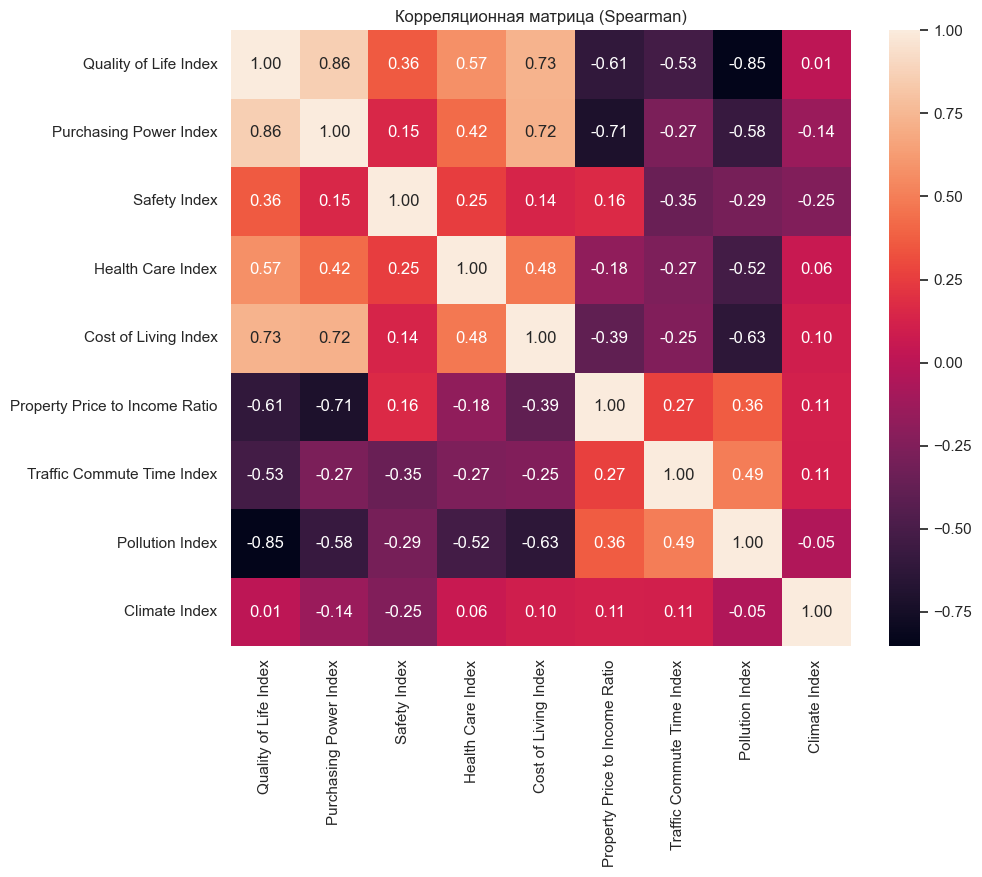

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(method='spearman'), annot=True, fmt=".2f")
plt.title("Корреляционная матрица (Spearman)")
plt.show()

Видна высокая мультиколлинеарность. Например, Quality of Life Index имеет очень сильную положительную связь с Purchasing Power Index и Safety Index, а также сильную отрицательную связь с Pollution Index.

Использование линейных моделей на исходных признаках может привести к неустойчивым оценкам из-за мультиколлинеарности. С помощью PCA найдем независимые главные компоненты без существенной потери информации.

## Заполнение пропусков и масштабирование

In [14]:
from sklearn.preprocessing import RobustScaler
imputer = SimpleImputer(strategy='median') #медиана устойчива к выбросам
X_imp = imputer.fit_transform(X)

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=numeric_cols)
display(X_scaled.describe().round(3))

,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
count,279.000,279.000,279.000,279.000,279.000,279.000,279.000,279.000,279.000
mean,-0.081,-0.107,-0.003,-0.041,-0.061,0.145,0.085,0.027,-0.183
std,0.666,0.586,0.641,0.774,0.642,0.972,0.754,0.653,0.759
min,-2.691,-1.402,-1.632,-2.565,-1.237,-1.145,-1.425,-1.179,-2.961
25%,-0.546,-0.660,-0.461,-0.502,-0.612,-0.480,-0.459,-0.514,-0.614
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.454,0.340,0.539,0.498,0.388,0.520,0.541,0.486,0.386
max,1.310,1.143,1.353,1.776,1.901,5.750,3.047,1.504,0.794


# Факторный анализ (Метод главных компонент — PCA)

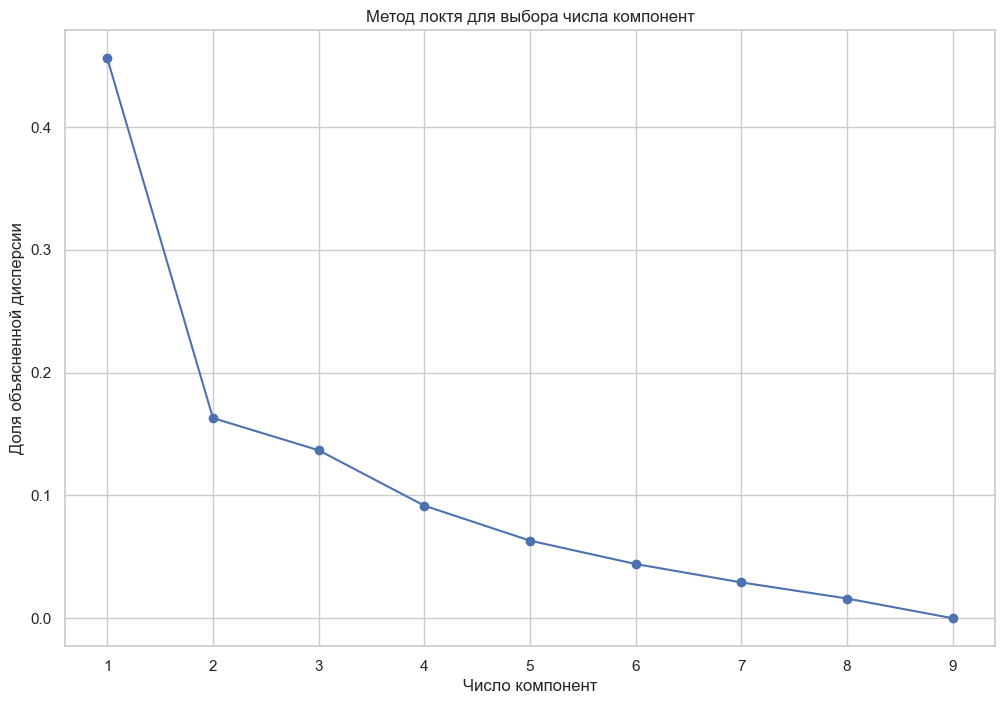

In [15]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel("Число компонент")
plt.ylabel("Доля объясненной дисперсии")
plt.title("Метод локтя для выбора числа компонент")
plt.show()

In [16]:
for n_components in range(1, len(numeric_cols) + 1):
    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    explained_variance = pca.explained_variance_ratio_.sum()
    print(f"Компоненты: {n_components}, Объясненная дисперсия: {explained_variance:.2%}")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)


Компоненты: 1, Объясненная дисперсия: 45.59%
Компоненты: 2, Объясненная дисперсия: 61.89%
Компоненты: 3, Объясненная дисперсия: 75.57%
Компоненты: 4, Объясненная дисперсия: 84.74%
Компоненты: 5, Объясненная дисперсия: 91.06%
Компоненты: 6, Объясненная дисперсия: 95.47%
Компоненты: 7, Объясненная дисперсия: 98.39%
Компоненты: 8, Объясненная дисперсия: 100.00%
Компоненты: 9, Объясненная дисперсия: 100.00%


За оптимальное количество компонент было выбрано 5

In [17]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

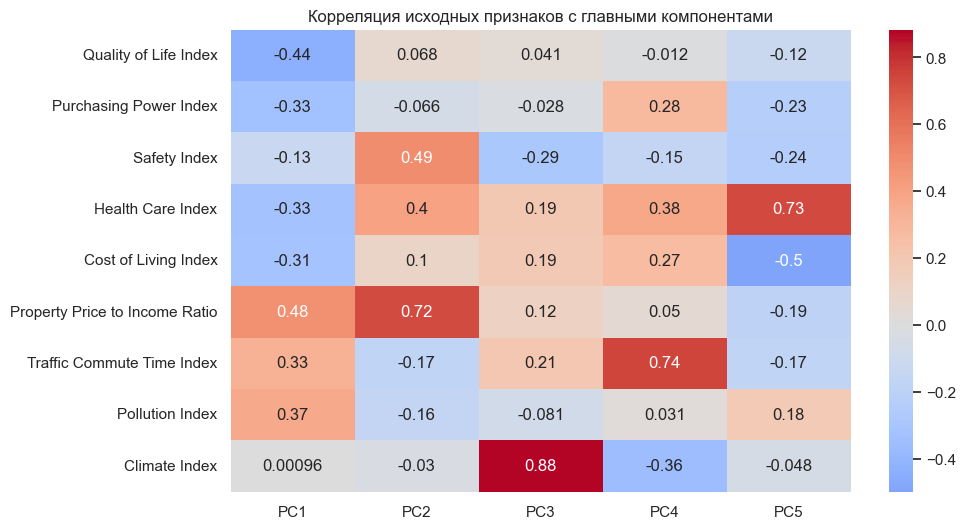

In [18]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index=X_scaled.columns)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция исходных признаков с главными компонентами')
plt.show()

1. PC1: Богатство и комфорт
* **Признаки:** `Quality of Life` (0.47), `Purchasing Power` (0.41), `Pollution` (-0.41).
* **Смысл:** Чем выше значение, тем богаче, чище и комфортнее город.
* *Примеры:* Западная Европа, Австралия.

2. PC2: Безопасность
* **Признаки:** `Safety Index` (0.71).
* **Смысл:** Чем выше значение, тем безопаснее город.
* *Примеры:* Высокий PC2 — Мюнхен, Доха; Низкий PC2 — города Латинской Америки.

3. PC3: Курорт
* **Признаки:** `Climate Index` (0.72), `Property Price to Income Ratio` (0.50).
* **Смысл:** Выделяет города с идеальной погодой, где из-за привлекательности климата недвижимость становится недоступной для местных.
* *Примеры:* Лиссабон, Лос-Анджелес, Барселона.

4. PC4: Пробки
* **Признаки:** `Traffic Commute Time Index` (0.71).
* **Смысл:** Выделяет мегаполисы, которые стоят в пробках.

5. PC5: Структура расходов (покупки vs недвижимость)
* **Признаки:** `Cost of Living Index` (0.45), `Property Price to Income Ratio` (-0.65).
* **Смысл:** Она разделяет "дорогие для жизни" города и "недоступные для покупки жилья" города.
    * **Высокий PC5 (Дорого жить, легко купить жилье):** Города, где дорогие продукты и услуги, но зарплаты позволяют купить жилье быстрее (США, Швейцария).
    * **Низкий PC5 (Дешево жить, сложно купить жилье):** Города, где еда и транспорт дешевые, но копить на квартиру нужно 50 лет из-за низких зарплат и пузыря недвижимости (Китай, Вьетнам, Филиппины).

In [19]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

# Кластерный анализ

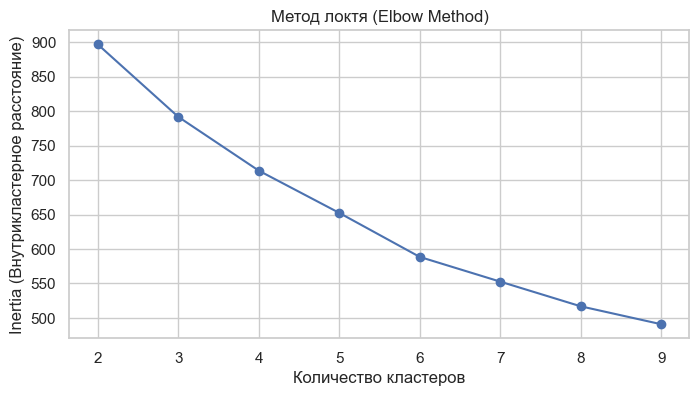

In [20]:
# выбор оптимального числа кластеров для KMeans с помощью метода локтя
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Метод локтя (Elbow Method)')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia (Внутрикластерное расстояние)')
plt.show()

По методу локтя оптимальное число кластеров для KMeans - 6

In [21]:
n_clusters = 6

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
# выбор оптимального числа кластеров для AgglomerativeClustering
def plot_dendrogram(X, method="single"):
    Z = linkage(X, method=method, metric='euclidean')
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90.)
    plt.title(f"Дендрограмма (метод {method})")
    plt.xlabel("Объекты/кластеры")
    plt.ylabel("Расстояние агломерации")
    plt.show()
    return Z

def agglomerative_clustering(X, n_clusters, linkage_method="single"):
    ag = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method,
        metric='euclidean'
    )
    labels = ag.fit_predict(X)
    return labels, ag

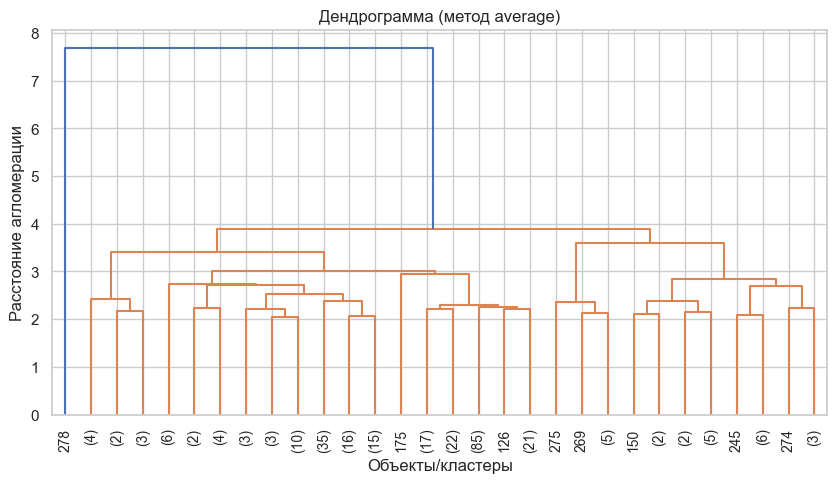

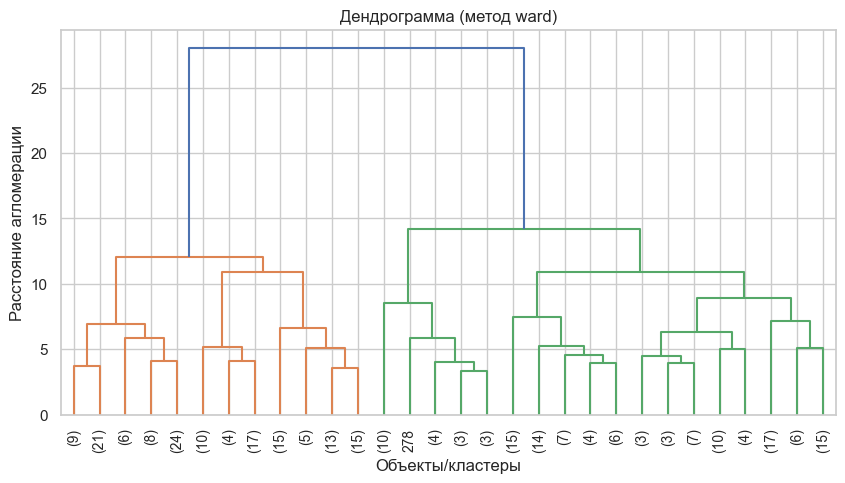

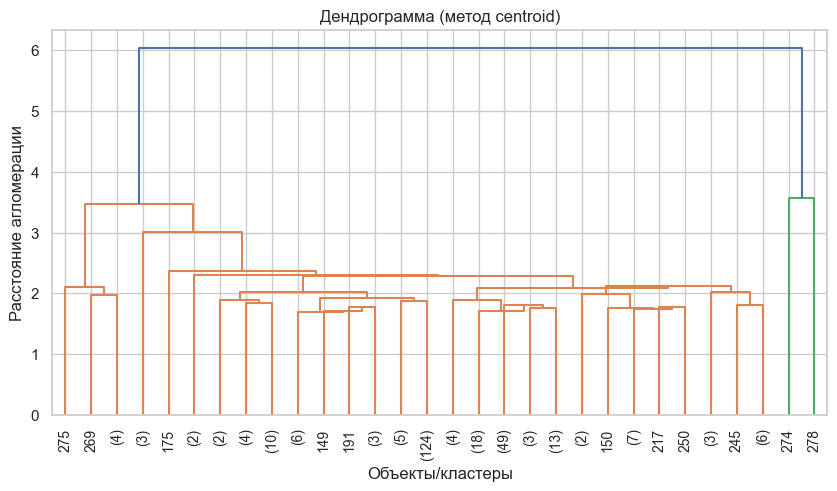

In [23]:
Z_centroid = plot_dendrogram(X_scaled, method="average")
Z_centroid = plot_dendrogram(X_scaled, method="ward")
Z_centroid = plot_dendrogram(X_scaled, method="centroid")

По дендрограмме оптимальное число кластеров - 4-6

Для однообразия примем одинаковое число кластеров для каждого метода

In [24]:
n_clusters = 6

## Построение базовых моделей

In [25]:
base_models = [
    KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
    KMeans(n_clusters=n_clusters, random_state=100, n_init=10),
    AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
    AgglomerativeClustering(n_clusters=n_clusters, linkage='average'),
    GaussianMixture(n_components=n_clusters, random_state=42)
]

In [26]:
def evaluate(X, labels, y_true=None):
    metrics = {}
    try:
        metrics['Silhouette'] = silhouette_score(X, labels)
    except Exception:
        metrics['Silhouette'] = np.nan
    try:
        metrics['CH'] = calinski_harabasz_score(X, labels)
    except Exception:
        metrics['CH'] = np.nan
    if y_true is not None:
        metrics['ARI'] = adjusted_rand_score(y_true, labels)
    return metrics

In [27]:
def evaluate_models(models, X, y_true=None):
    results = []
    for m in models:
        name = type(m).__name__
        if isinstance(m, KMeans):
            name += f"_rs{m.random_state}"
        if isinstance(m, AgglomerativeClustering):
            name += f"_{m.linkage}"
        if isinstance(m, GaussianMixture):
            labels = m.fit_predict(X)
        else:
            labels = m.fit_predict(X)
        metrics = evaluate(X, labels, y_true)
        results.append((name, metrics, labels))
    return results

base_results = evaluate_models(base_models, X_scaled)
print("Результаты базовых моделей:")
for name, met, labels in base_results:
    print(name, met)

Результаты базовых моделей:
KMeans_rs42 {'Silhouette': np.float64(0.1780950054486615), 'CH': np.float64(67.26648931068351)}
KMeans_rs100 {'Silhouette': np.float64(0.17850229032517426), 'CH': np.float64(66.73515983556565)}
AgglomerativeClustering_ward {'Silhouette': np.float64(0.16309401828016734), 'CH': np.float64(59.41280413196978)}
AgglomerativeClustering_average {'Silhouette': np.float64(0.21778261105485988), 'CH': np.float64(48.58017596164542)}
GaussianMixture {'Silhouette': np.float64(0.14533118904829498), 'CH': np.float64(54.305046572737155)}


## Ансамблевая кластеризация

In [28]:
# ансамбль из K-means, Agglomerative (2 вида) и GMM.

class ClusterEnsemble:
    def __init__(self, base_models, consensus='coassociation'):
        self.base_models = base_models
        self.consensus = consensus
        self.labels_list = []
        self.n = None

    def fit_predict(self, X):
        self.labels_list = []
        for model in self.base_models:
            if isinstance(model, GaussianMixture):
                labels = model.fit_predict(X)
            else:
                labels = model.fit_predict(X)
            self.labels_list.append(labels)
        self.n = X.shape[0]
        if self.consensus == 'coassociation':
            return self._consensus_coassoc()
        else:
            return self._consensus_mirkin()

    def _consensus_coassoc(self):
        n = self.n
        CA = np.zeros((n, n), dtype=float)
        for labels in self.labels_list:
            for i in range(n):
                for j in range(n):
                    if labels[i] == labels[j]:
                        CA[i, j] += 1
        CA /= len(self.labels_list)
        distance_matrix = 1 - CA
        agg = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
        labels = agg.fit_predict(distance_matrix)
        self.coassoc_matrix_ = CA
        return labels

    def _mirkin_distance(self, a, b):
        n = len(a)
        dist = 0
        for i in range(n):
            for j in range(i+1, n):
                same_a = (a[i] == a[j])
                same_b = (b[i] == b[j])
                if same_a != same_b:
                    dist += 1
        return dist

    def _consensus_mirkin(self):
        best_labels = None
        min_total = float('inf')
        for cand in self.labels_list:
            total = sum(self._mirkin_distance(cand, other) for other in self.labels_list)
            if total < min_total:
                min_total = total
                best_labels = cand
        return best_labels


In [29]:
ensemble_models_1 = [KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                   AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
                   GaussianMixture(n_components=n_clusters, random_state=42)]
ensemble_coassoc_1 = ClusterEnsemble(ensemble_models_1, consensus='coassociation')
labels_ens_coassoc_1 = ensemble_coassoc_1.fit_predict(X_scaled)
metrics_ens_coassoc_1 = evaluate(X_scaled, labels_ens_coassoc_1)
print("Ансамбль коассоциация (ward):", metrics_ens_coassoc_1)

Ансамбль коассоциация (ward): {'Silhouette': np.float64(0.16482813686765824), 'CH': np.float64(61.30949388590323)}


In [30]:
ensemble_models_2 = [KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                   AgglomerativeClustering(n_clusters=n_clusters, linkage='average'),
                   GaussianMixture(n_components=n_clusters, random_state=42)]
ensemble_coassoc_2 = ClusterEnsemble(ensemble_models_2, consensus='coassociation')
labels_ens_coassoc_2 = ensemble_coassoc_2.fit_predict(X_scaled)
metrics_ens_coassoc_2 = evaluate(X_scaled, labels_ens_coassoc_2)
print("Ансамбль коассоциация (average):", metrics_ens_coassoc_2)

Ансамбль коассоциация (average): {'Silhouette': np.float64(0.16893935680166278), 'CH': np.float64(63.576904418103986)}


In [31]:
#консенсус через расстояние Миркина (выбор наилучшего базового разбиения)
ensemble_mirkin_1 = ClusterEnsemble(ensemble_models_1, consensus='mirkin')
labels_ens_mirkin_1 = ensemble_mirkin_1.fit_predict(X_scaled)
metrics_ens_mirkin_1 = evaluate(X_scaled, labels_ens_mirkin_1)
print("Ансамбль Миркин (ward):", metrics_ens_mirkin_1)

ensemble_mirkin_2 = ClusterEnsemble(ensemble_models_2, consensus='mirkin')
labels_ens_mirkin_2 = ensemble_mirkin_1.fit_predict(X_scaled)
metrics_ens_mirkin_2 = evaluate(X_scaled, labels_ens_mirkin_2)
print("Ансамбль Миркин (average):", metrics_ens_mirkin_2)

Ансамбль Миркин (ward): {'Silhouette': np.float64(0.1780950054486615), 'CH': np.float64(67.26648931068351)}
Ансамбль Миркин (average): {'Silhouette': np.float64(0.1780950054486615), 'CH': np.float64(67.26648931068351)}


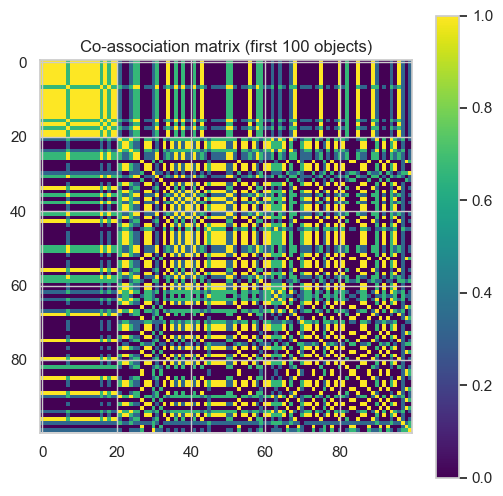

In [32]:
def plot_coassoc_matrix(CA, N=100):
    CA_small = CA[:N, :N]
    plt.figure(figsize=(6,6))
    plt.imshow(CA_small, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar()
    plt.title(f"Co-association matrix (first {N} objects)")
    plt.show()

plot_coassoc_matrix(ensemble_coassoc_1.coassoc_matrix_, N=100)

In [33]:
# Определим повышает ли GMM разнообразие ансамбля 
# (через среднее попарное расстояние Миркина)
from itertools import combinations

def mean_pairwise_mirkin(labels_list):
    dists = []
    for a,b in combinations(labels_list, 2):
        n = len(a)
        dist = 0
        for i in range(n):
            for j in range(i+1, n):
                if (a[i]==a[j]) != (b[i]==b[j]):
                    dist += 1
        dists.append(dist)
    return np.mean(dists)

models_with_gmm    = [KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                      AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
                      GaussianMixture(n_components=n_clusters, random_state=42)]

models_without_gmm = [KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                      AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
                      KMeans(n_clusters=n_clusters, random_state=100, n_init=10)]

def get_labels_list(models, X):
    labs = []
    for m in models:
        if isinstance(m, GaussianMixture):
            labs.append(m.fit_predict(X))
        else:
            labs.append(m.fit_predict(X))
    return labs

labs_with = get_labels_list(models_with_gmm, X_scaled)
labs_without = get_labels_list(models_without_gmm, X_scaled)
mpm_with = mean_pairwise_mirkin(labs_with)
mpm_without = mean_pairwise_mirkin(labs_without)
print("Mean pairwise Mirkin distance: with GMM =", mpm_with, ", without GMM =", mpm_without)

Mean pairwise Mirkin distance: with GMM = 5886.666666666667 , without GMM = 5105.333333333333


## Выбор лучшей модели

In [34]:
from sklearn.metrics import davies_bouldin_score, r2_score

def calculate_clustering_r2(X, labels):
    unique_labels = np.unique(labels)
    centroids = {}
    for l in unique_labels:
        centroids[l] = X[labels == l].mean(axis=0)
    X_pred = np.array([centroids[l] for l in labels])
    return r2_score(X, X_pred, multioutput='variance_weighted')

rows = []

for name, metrics, labels in base_results:
    labels = np.asarray(labels)
    unique, counts = np.unique(labels, return_counts=True)
    
    db_score = davies_bouldin_score(X_scaled, labels)
    r2_val = calculate_clustering_r2(X_scaled, labels)
    
    rows.append({
        'model': name,
        'Silhouette': metrics.get('Silhouette', np.nan),
        'CH': metrics.get('CH', np.nan),
        'Davies-Bouldin': db_score,
        'R2': r2_val,
        'cluster_sizes': ','.join(map(str, sorted(counts, reverse=True)))
    })

ensemble_data = [
    ('Ensemble_Coassoc_ward', labels_ens_coassoc_1, metrics_ens_coassoc_1),
    ('Ensemble_Mirkin_ward', labels_ens_mirkin_1, metrics_ens_mirkin_1),
    ('Ensemble_Coassoc_average', labels_ens_coassoc_2, metrics_ens_coassoc_2),
    ('Ensemble_Mirkin_average', labels_ens_mirkin_2, metrics_ens_mirkin_2),
]

for en_name, labels_arr, metrics_dict in ensemble_data:
    labels = np.asarray(labels_arr)
    unique, counts = np.unique(labels, return_counts=True)
    
    db_score = davies_bouldin_score(X_scaled, labels)
    r2_val = calculate_clustering_r2(X_scaled, labels)
    
    rows.append({
        'model': en_name,
        'Silhouette': metrics_dict.get('Silhouette', np.nan),
        'CH': metrics_dict.get('CH', np.nan),
        'Davies-Bouldin': db_score,
        'R2': r2_val,
        'cluster_sizes': ','.join(map(str, sorted(counts, reverse=True)))
    })

df_base_results = pd.DataFrame(rows).set_index('model')

display(df_base_results.sort_values(by='Silhouette', ascending=False))

,Silhouette,CH,Davies-Bouldin,R2,cluster_sizes
model,,,,,
AgglomerativeClustering_average,0.217783,48.580176,1.175425,0.470829,"147,94,21,9,7,1"
KMeans_rs100,0.178502,66.735160,1.587497,0.550007,"77,57,55,43,26,21"
KMeans_rs42,0.178095,67.266489,1.539533,0.551969,"63,61,60,40,36,19"
Ensemble_Mirkin_ward,0.178095,67.266489,1.539533,0.551969,"63,61,60,40,36,19"
Ensemble_Mirkin_average,0.178095,67.266489,1.539533,0.551969,"63,61,60,40,36,19"
Ensemble_Coassoc_average,0.168939,63.576904,1.633543,0.537981,"67,64,60,36,32,20"
Ensemble_Coassoc_ward,0.164828,61.309494,1.634752,0.528943,"71,69,48,38,35,18"
AgglomerativeClustering_ward,0.163094,59.412804,1.660182,0.521106,"68,65,48,46,31,21"
GaussianMixture,0.145331,54.305047,1.664532,0.498646,"77,73,43,33,33,20"


Модель AgglomerativeClustering_average: самый высокий Silhouette Score (0.218), но она непригодна из-за сильного дисбаланса кластеров

KMeans_rs42 и ансамбли Ensemble_Mirkin (и ward, и average) показывают одинаковые результаты:
* Silhouette=0.178 (на 0.0005 меньше чем у KMeans_rs100)
* Самый высокий показатель CH
* Сбалансированные размеры кластеров

KMeans_rs100: немного выше силуэт, но немного ниже CH.

Метод Миркина ищет существующее разбиение из списка базовых моделей, которое ближе всего ко всем остальным (в данном случае это разбиение K-Means).

Gaussian Mixture (GMM) дает самые низкие показатели. Вероятно, данные в этом признаковом пространстве лучше описываются сферическими кластерами, чем эллипсоидными.

**Вывод:** 

- Лучшая модель: Kmeans (random_state=100). 
- Также для автоматического выбора наилучшей базовой модели можно использовать Ensemble_Mirkin, если вычислительные и временные затраты не важны.

In [35]:
kmeans = KMeans(n_clusters=n_clusters, random_state=100, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

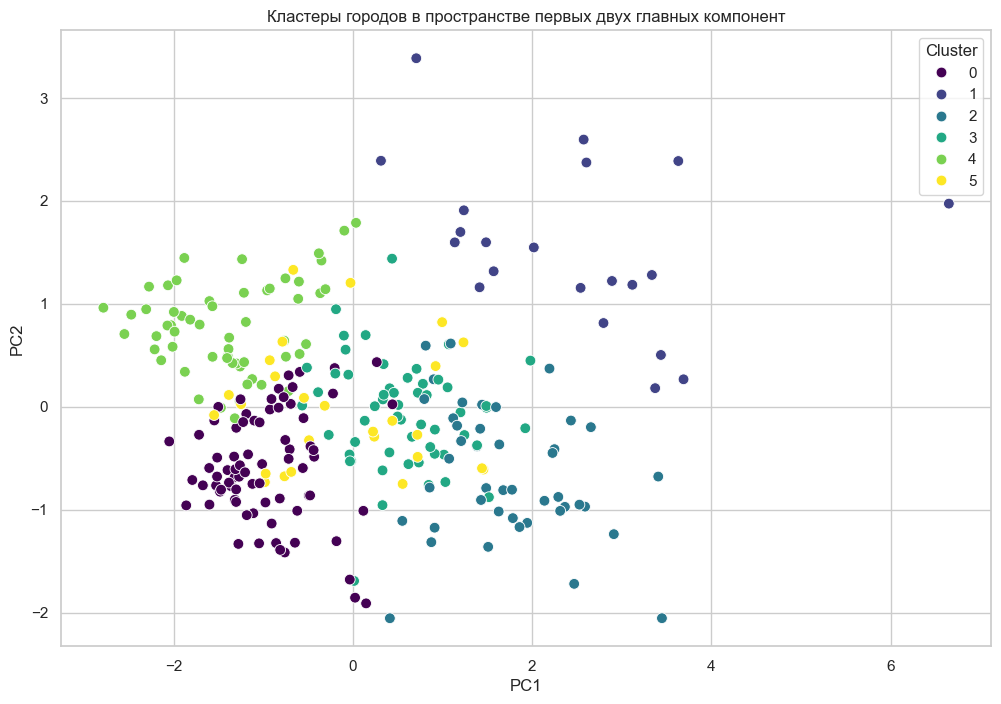

In [36]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['Cluster'], palette='viridis', s=60)
plt.title('Кластеры городов в пространстве первых двух главных компонент')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

## Интерпретация кластеров

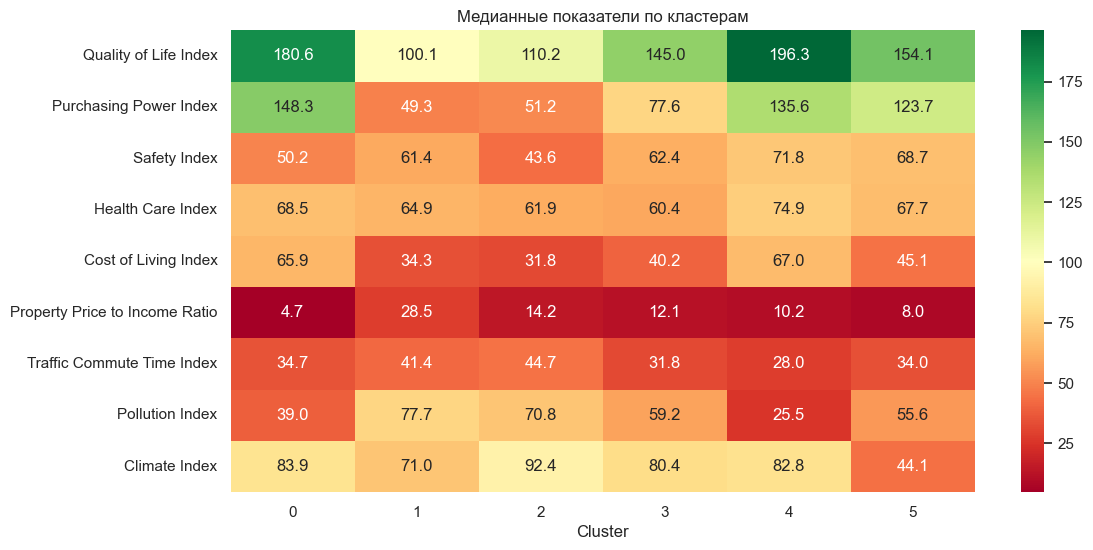

In [37]:
cluster_profile = df.groupby('Cluster')[numeric_cols].median().T

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Медианные показатели по кластерам')
plt.show()

In [38]:
for c in range(n_clusters):
    cities_in_cluster = df[df['Cluster'] == c]['City'].head(10).values
    print(f"Кластер {c}: {', '.join(cities_in_cluster)} ...")

Кластер 0: Perth, Raleigh,NC, Madison,WI, Melbourne, Kansas City,MO, Omaha,NE, Cincinnati,OH, Wellington, Portland,OR, Saint Louis,MO ...
Кластер 1: Seoul, Shenzhen, Taipei, Hong Kong, Guangzhou, Hamilton, Shanghai, Yerevan, Beijing, Pattaya ...
Кластер 2: Bangalore, Los Angeles,CA, Johannesburg, Florianopolis, Coimbatore, Montevideo, London, Noida, Quito, Athens ...
Кластер 3: Trieste, Timisoara, Cluj-Napoca, Queretaro (Santiago de Querétaro), Poznan, Riga, Limassol, Kaliningrad, Bratislava, Florence ...
Кластер 4: The Hague (Den Haag), Groningen, Eindhoven, Bern, Utrecht, Basel, Stavanger, Valencia, Luxembourg, Rotterdam ...
Кластер 5: Ottawa, Jeddah (Jiddah), Ad Dammam, Quebec City, Edmonton, Dubai, Abu Dhabi, Calgary, Doha, Manama ...


**Кластер 0: Богатые, но опасные**
* **Плюсы:**
  * Самая высокая покупательная способность
  * Самое доступное жилье относительно доходов
  * Хороший климат
* **Минусы:**
  * Очень низкий уровень безопасности: на уровне стран третьего мира
  * Средняя оценка качества здравоохранения (хуже чем у кластера 2)
* **Вывод:** Города с хорошей экономикой, где легко купить дом и заработать состояние, но приходится мириться с высокой преступностью.
* **Примеры:** Perth, Raleigh,NC, Melbourne, Kansas City,MO, Cincinnati,OH, Wellington, Portland,OR, Saint Louis,MO, Seattle,WA, San Antonio,TX.

**Кластер 1: Перенаселенные мегаполисы**
* **Плюсы:**
  * Самая низкая стоимость жизни
  * Хороший климат
* **Минусы:**
  * Самая загрязнененная среда
  * Самый тяжелые пробки
  * Очень низкая покупательная способность
* **Вывод:** Перенаселенные мегаполисы, с большими проблемами с экономикой, экологией и пробками.
* **Примеры:** Bangalore, Coimbatore, Moscow, Noida, Quito, Gurgaon, Saint Petersburg, Istanbul, Belo Horizonte, San Jose.

**Кластер 2: Лучшие города для жизни**
* **Плюсы:**
  * Самое высокое качество жизни
  * Самый высокий уровень безопасности
  * Самый высокий уровень медицины
  * Высокая покупательная способность
  * Минимальное загрязнение окружающей среды
* **Минусы:**
  * Высокая стоимость жизни (повседневных товаров), хотя она компенсируется высокими доходами
* **Вывод:** Самые комфортные, чистые и безопасные города.
* **Примеры:** The Hague (Den Haag), Groningen, Eindhoven, Bern, Utrecht, Basel, Stavanger, Valencia, Luxembourg, Rotterdam.

**Кластер 3: Города для удаленщиков**
* **Плюсы:**
  * Низкая стоимость жизни (повседневных товаров) 
  * Хороший уровень безопасности
  * Хорошая экология
  * Умеренный трафик
* **Минусы:**
  * Не лучший климат
  * Покупательная способность средняя — не подходит для сверхзароботков
* **Вывод:** Города, предлагающие европейский уровень комфорта и безопасности за небольшие деньги.
* **Примеры:** Trieste, Timisoara, Cluj-Napoca, Queretaro (Santiago de Querétaro), Poznan, Riga, Limassol, Windhoek, Kaliningrad, Bratislava

**Кластер 4: Жилищный кризис**
* **Плюсы:**
  * Низкая стоимость жизни (повседневных товаров)
* **Минусы:**
  * Катастрофическая недоступность жилья
  * Высокое загрязнение среды
  * Низкая покупательная способность
  * Тратится очень много времени в пути на работу (пробки)
* **Вывод:** Города с огромным разрывом между зарплатами и ценами на недвижимость, часто перенаселенные и экологически неблагополучные.
* **Примеры:** Seoul, Shenzhen, Taipei, Hong Kong, Guangzhou, Hamilton, Shanghai, Yerevan, Beijing, Bangkok.

**Кластер 5: Богатые с суровым климатом**
* **Плюсы:**
  * Высокая покупательная способность
  * Высокий уровень безопасности
  * Хорошая экология
* **Минусы:**
  * Самый низкий климатический индекс
  * Достаточно высокая стоимость жизни
* **Вывод:** Развитые и безопасные города, где высокий уровень жизни достигается вопреки суровому климату.
* **Примеры:** Madison,WI, Muscat, Colorado Springs,CO, Ottawa, Minneapolis,MN, Jeddah (Jiddah), Ad Dammam, Denver,CO, Salt Lake City,UT, Quebec City

Такая кластеризация поможет ответить на такие вопросы как:

* выбор места для переезда ("ищу безопасную и комфортную жизнь, готов платить за это" => Кластер 2)
* поиск работы (стоит ли высокая зарплата в городе из Кластера 4 борьбы за жилье и долгих поездок на работу)
* куда инвестировать (недвижимость, безопасность, инфраструктура, экология)
* где открывать офис (например, штаб-квартира для международных экспертов)
* как привлекать таланты (какие бонусы предлагать сотрудникам из разных городов)
* определить целевой рынок для продаж (premium-товары в городах из кластеров 0 и 5)

## Поиск аномальных городов

In [39]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_scaled)

df['Is_Outlier'] = iso_forest.predict(X_scaled)
df['Anomaly_Score'] = iso_forest.decision_function(X_scaled) 

anomalies = df[df['Is_Outlier'] == -1].sort_values(by='Anomaly_Score')
anomalies


,Rank,City_raw,City,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Cluster,Is_Outlier,Anomaly_Score
278,NaN,"Lagos, Nigeria",Lagos,Nigeria,8.2,10.9,31.6,47.5,28.9,54.1,70.0,88.9,60.8,1,-1,-0.115132
275,NaN,"Dhaka, Bangladesh",Dhaka,Bangladesh,68.0,42.7,38.3,39.7,23.5,12.0,61.0,94.6,71.3,2,-1,-0.020784
274,NaN,"Colombo, Sri Lanka",Colombo,Sri Lanka,73.1,21.0,57.7,71.8,34.1,39.4,59.5,60.0,59.1,1,-1,-0.010883


In [40]:
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.copod import COPOD

contamination = 0.05

classifiers = {
    'KNN': KNN(contamination=contamination),
    'IForest': IForest(contamination=contamination, random_state=42),
    'COPOD': COPOD(contamination=contamination)
}

for i, (name, clf) in enumerate(classifiers.items()):
    clf.fit(X_scaled)
    col_name = f'anomaly{i+1}'
    df[col_name] = clf.labels_

df['anomaly_sum'] = df['anomaly1'] + df['anomaly2'] + df['anomaly3']
df['anomaly'] = (df['anomaly_sum'] >= 2).astype(int)

print(f"Аномалий: {df['anomaly'].sum()}")

Аномалий: 11


In [41]:
df

,Rank,City_raw,City,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,...,Pollution Index,Climate Index,Cluster,Is_Outlier,Anomaly_Score,anomaly1,anomaly2,anomaly3,anomaly_sum,anomaly
0,NaN,"The Hague (Den Haag), Netherlands",The Hague (Den Haag),Netherlands,235.1,165.7,80.0,82.7,67.7,5.7,...,17.5,90.6,4,1,0.053855,0,0,0,0,0
1,NaN,"Groningen, Netherlands",Groningen,Netherlands,229.1,161.8,77.9,78.6,61.0,5.2,...,18.8,83.5,4,1,0.090706,0,0,0,0,0
2,NaN,"Eindhoven, Netherlands",Eindhoven,Netherlands,226.6,159.2,79.1,80.4,66.3,6.5,...,19.2,85.4,4,1,0.110205,0,0,0,0,0
3,NaN,"Bern, Switzerland",Bern,Switzerland,219.9,192.2,77.6,71.3,103.4,8.9,...,19.7,76.0,4,1,0.044920,0,1,0,1,0
4,NaN,"Utrecht, Netherlands",Utrecht,Netherlands,216.4,140.3,78.0,83.6,69.0,8.4,...,21.9,87.2,4,1,0.135409,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,NaN,"Colombo, Sri Lanka",Colombo,Sri Lanka,73.1,21.0,57.7,71.8,34.1,39.4,...,60.0,59.1,1,-1,-0.010883,1,1,1,3,1
275,NaN,"Dhaka, Bangladesh",Dhaka,Bangladesh,68.0,42.7,38.3,39.7,23.5,12.0,...,94.6,71.3,2,-1,-0.020784,1,1,1,3,1
276,NaN,"Tehran, Iran",Tehran,Iran,67.3,27.8,42.9,53.3,24.4,28.0,...,80.3,71.0,1,1,0.045595,0,1,1,2,1
277,NaN,"Manila, Philippines",Manila,Philippines,62.5,41.6,35.3,62.5,34.3,28.6,...,89.8,61.2,1,1,0.045819,1,1,1,3,1


In [42]:
def explain_anomaly(row, stats):
    reason = ""

    if row['anomaly'] == 0:
        return "Normal"
    
    if row['Property Price to Income Ratio'] > stats['Property Price to Income Ratio']['95%']:
        reason += "Экстремальная недоступность жилья. "
        
    if row['Traffic Commute Time Index'] > stats['Traffic Commute Time Index']['95%']:
        reason += "Экстремальный трафик. "

    if row['Pollution Index'] > stats['Pollution Index']['95%']:
        reason += "Экологическая катастрофа. "
        
    if row['Safety Index'] < stats['Safety Index']['5%']:
        reason += "Критически низкая безопасность. "
        
    if row['Climate Index'] < stats['Climate Index']['5%']:
        reason += "Экстремальные климатические условия. "
    
    if row['Health Care Index'] < stats['Health Care Index']['5%']:
        reason += "Аномально низкое качество медицины. "
    
    if row['Health Care Index'] > stats['Health Care Index']['95%']:
        reason += "Аномально высокое качество медицины. "

    if row['Purchasing Power Index'] > stats['Purchasing Power Index']['95%']:
        reason += "Аномально высокие доходы. "
    
    if row['Purchasing Power Index'] < stats['Purchasing Power Index']['5%']:
        reason += "Критически низкие доходы. "

    if row['Cost of Living Index'] > stats['Cost of Living Index']['95%']:
        reason += "Аномальная стоимость жизни. "
    
    if row['Quality of Life Index'] < stats['Quality of Life Index']['5%']:
        reason += "Общий упадок качества жизни. "
    
    if row['Quality of Life Index'] > stats['Quality of Life Index']['95%']:
        reason += "Утопия (Идеальные показатели качества жизни). "

    return reason

stats = df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95]).to_dict()

df['anomaly_reason'] = df.apply(lambda row: explain_anomaly(row, stats), axis=1)

anomalies_list = df[df['anomaly'] == 1].sort_values(by='anomaly_reason')

for index, row in anomalies_list.iterrows():
    print(f"{row['City']}: {row['anomaly_reason']}")

Alexandria: Аномально низкое качество медицины. Критически низкие доходы. Общий упадок качества жизни. 
Caracas: Критически низкая безопасность. Аномально низкое качество медицины. Критически низкие доходы. Общий упадок качества жизни. 
Cairo: Экологическая катастрофа. Аномально низкое качество медицины. Критически низкие доходы. Общий упадок качества жизни. 
Taipei: Экстремальная недоступность жилья. Аномально высокое качество медицины. 
Kathmandu: Экстремальная недоступность жилья. Экологическая катастрофа. Критически низкие доходы. Общий упадок качества жизни. 
Manila: Экстремальная недоступность жилья. Экологическая катастрофа. Общий упадок качества жизни. 
Colombo: Экстремальная недоступность жилья. Экстремальный трафик. Критически низкие доходы. Общий упадок качества жизни. 
Tehran: Экстремальная недоступность жилья. Экстремальный трафик. Критически низкие доходы. Общий упадок качества жизни. 
Lagos: Экстремальная недоступность жилья. Экстремальный трафик. Экологическая катастроф

**Практическая значимость поиска аномальных городов**

1. Релокация сотрудников
* При отправке сотрудников в города с экстремальной опасностью необходимо назначить обязательные протоколы безопасности и страхования.
* Города с меткой экстремальный трафиком и экологической катастрофой требуют надбавки за вред здоровью.

2. Инвестиции
* Входить в рынок недвижимости рискованно в городах, где спрос держится не на покупательной способности, а на спекуляциях или дефиците.
* Города с большими пробками и плохой экологией не подходят для штаб-квартир. Сотрудники будут стоять в пробках, а переманить топ-специалистов из-за рубежа почти невозможно.

3. Маркетинг
* В городах с критически низкими доходами при высокой стоимости жизни стандартные товары массового потребления могут оказаться предметом роскоши. Здесь нужны специальные бюджетные линейки продуктов.

4. Урбанистика и государственное управление
* Города с общим упадком качества жизни находятся на грани гуманитарной катастрофы и требуют приоритетного финансирования.
* В городах с аномальным трафиком и загрязнением, но без критического провала в доходах, экономический рост опережает развитие инфраструктуры. Власти должны срочно инвестировать в метро и очистные сооружения, иначе город станет непригодным для жизни.

5. Data Science (Качество моделей)
* Исключение аномалий может повысить точность прогноза для остальных 95% данных.

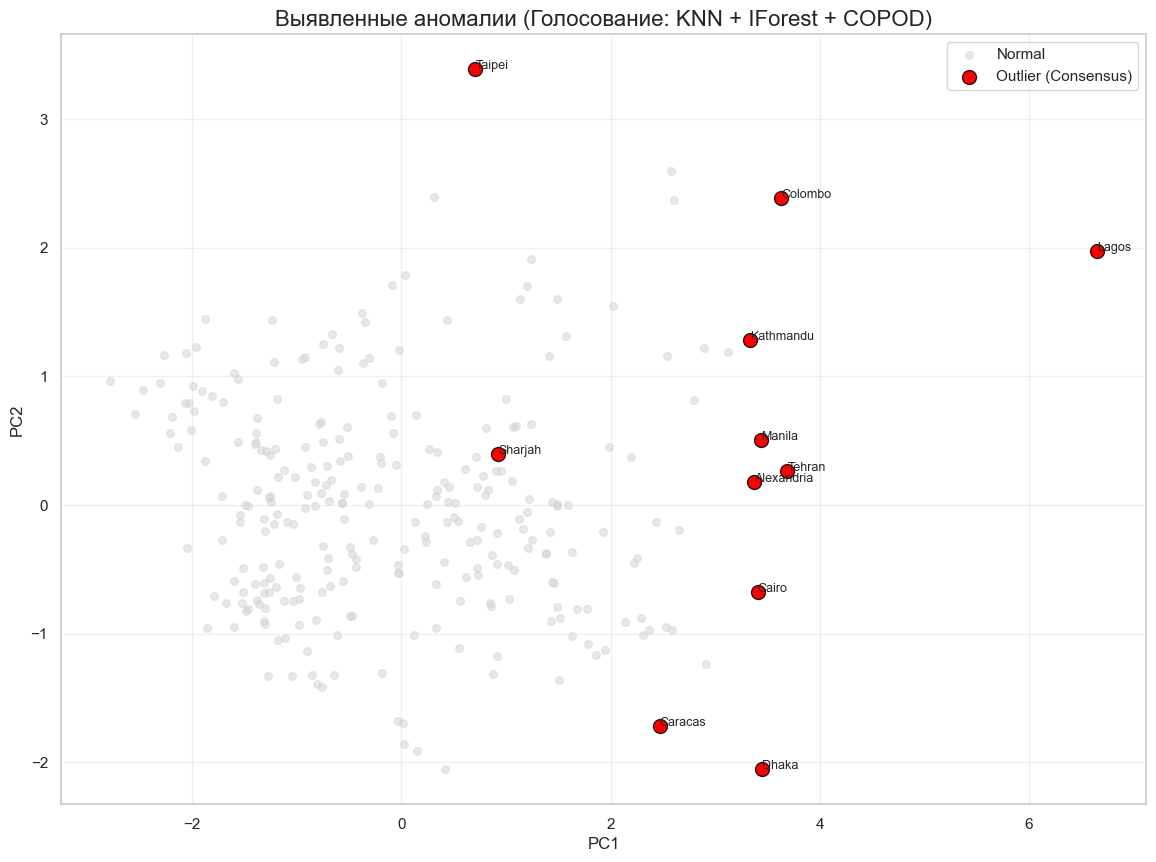

In [43]:
anomalies = df[df['anomaly'] == 1]
normals = df[df['anomaly'] == 0]

plt.figure(figsize=(14, 10))

plt.scatter(df_pca.loc[normals.index, 'PC1'], 
            df_pca.loc[normals.index, 'PC2'], 
            c='lightgrey', label='Normal', alpha=0.5, s=30)

plt.scatter(df_pca.loc[anomalies.index, 'PC1'], 
            df_pca.loc[anomalies.index, 'PC2'], 
            c='red', label='Outlier (Consensus)', s=100, edgecolors='k', linewidth=1)

texts = []
for i in anomalies.index:
    city_name = df.loc[i, 'City']
    label_text = f"{city_name}"
    
    plt.text(df_pca.loc[i, 'PC1'], df_pca.loc[i, 'PC2'], 
             label_text, fontsize=9)

plt.title('Выявленные аномалии (Голосование: KNN + IForest + COPOD)', fontsize=16)
plt.xlabel('PС1')
plt.ylabel('PС2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()